# AI-Enhanced Literate Programming Demo

This mock notebook is a self-contained computational essay for exploring AI-enhanced literate programming in Jupyter-style environments. It uses a synthetic SaaS customer-health dataset so the notebook has enough narrative, code, tables, and visualizations to later test ideas such as narrative-code synchronization, provenance summaries, critique agents, and adaptive explanation layers.

The flow is simple: generate data, derive business-facing features, visualize churn patterns, and train lightweight baseline models.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)

In [2]:
def make_customer_health_dataset(n_customers: int = 2200, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    analysis_date = pd.Timestamp("2026-01-01")

    signup_months = pd.date_range("2024-01-01", "2025-12-01", freq="MS")
    df = pd.DataFrame({
        "customer_id": np.arange(1000, 1000 + n_customers),
        "segment": rng.choice(["SMB", "Mid-Market", "Enterprise"], size=n_customers, p=[0.55, 0.30, 0.15]),
        "region": rng.choice(["North America", "Europe", "APAC", "LATAM"], size=n_customers, p=[0.42, 0.28, 0.20, 0.10]),
        "acquisition_channel": rng.choice(["Organic", "Partner", "Paid Search", "Outbound", "Community"], size=n_customers, p=[0.18, 0.22, 0.24, 0.18, 0.18]),
        "signup_date": pd.to_datetime(rng.choice(signup_months, size=n_customers)),
    })

    df["tenure_months"] = ((analysis_date.year - df["signup_date"].dt.year) * 12 + (analysis_date.month - df["signup_date"].dt.month)).clip(lower=1)

    segment_base_mrr = df["segment"].map({"SMB": 240, "Mid-Market": 960, "Enterprise": 2900})
    segment_login_base = df["segment"].map({"SMB": 10, "Mid-Market": 18, "Enterprise": 25})
    segment_adoption_base = df["segment"].map({"SMB": 0.42, "Mid-Market": 0.58, "Enterprise": 0.67})
    segment_ticket_base = df["segment"].map({"SMB": 2.6, "Mid-Market": 2.1, "Enterprise": 1.8})
    onboarding_base = df["segment"].map({"SMB": 4.0, "Mid-Market": 10.0, "Enterprise": 24.0})

    df["monthly_recurring_revenue"] = np.clip(rng.normal(segment_base_mrr, segment_base_mrr * 0.18), 60, None).round(2)
    df["product_logins_last_30"] = np.clip(rng.normal(segment_login_base + (df["acquisition_channel"] == "Community") * 2.5, 4.0), 1, None).round().astype(int)
    df["active_days_last_30"] = np.clip(df["product_logins_last_30"] + rng.normal(4.0, 3.0, size=n_customers), 1, 30).round().astype(int)
    df["feature_adoption_rate"] = np.clip(rng.normal(segment_adoption_base + df["tenure_months"] * 0.01, 0.12), 0.05, 0.98).round(3)
    df["support_tickets_last_90"] = rng.poisson(segment_ticket_base + (df["feature_adoption_rate"] < 0.35) * 1.2 + (df["region"] == "LATAM") * 0.4).astype(int)
    df["nps_score"] = np.clip(rng.normal(35 + 35 * df["feature_adoption_rate"] - 2.5 * df["support_tickets_last_90"], 14), -40, 90).round(0)
    df["onboarding_hours"] = np.clip(rng.normal(onboarding_base, 3.0), 1, None).round(1)
    df["renewal_discount_pct"] = np.clip(rng.normal(np.where(df["segment"].eq("Enterprise"), 9, 4) + np.where(df["acquisition_channel"].eq("Paid Search"), 2, 0), 3), 0, 25).round(1)
    df["payment_failures_last_6m"] = rng.poisson(0.25 + (df["region"] == "LATAM") * 0.3 + (df["segment"] == "SMB") * 0.2).astype(int)
    df["usage_growth_pct"] = np.clip(rng.normal(6 + 26 * df["feature_adoption_rate"] - 1.5 * df["support_tickets_last_90"], 12), -40, 55).round(1)
    df["expansion_intent_score"] = np.clip(rng.normal(45 + 30 * df["feature_adoption_rate"] + 0.08 * df["nps_score"] + 0.02 * df["monthly_recurring_revenue"], 11), 5, 99).round(1)

    risk_logit = (-0.9 - 3.0 * df["feature_adoption_rate"] - 0.07 * df["active_days_last_30"] + 0.38 * df["support_tickets_last_90"] - 0.025 * df["nps_score"] + 0.55 * df["payment_failures_last_6m"] - 0.03 * df["usage_growth_pct"] - 0.025 * df["expansion_intent_score"] + 0.12 * df["renewal_discount_pct"] + np.where(df["segment"].eq("SMB"), 0.55, 0) + np.where(df["acquisition_channel"].eq("Paid Search"), 0.28, 0) + np.where(df["region"].eq("LATAM"), 0.25, 0) + np.where(df["tenure_months"] < 6, 0.55, 0))
    churn_probability = 1 / (1 + np.exp(-risk_logit))
    df["is_churned"] = rng.binomial(1, churn_probability)
    df["cohort_month"] = df["signup_date"].dt.to_period("M").dt.to_timestamp()

    nps_missing = rng.choice(df.index, size=int(n_customers * 0.05), replace=False)
    growth_missing = rng.choice(df.index, size=int(n_customers * 0.03), replace=False)
    df.loc[nps_missing, "nps_score"] = np.nan
    df.loc[growth_missing, "usage_growth_pct"] = np.nan

    return df.sort_values("signup_date").reset_index(drop=True)

In [3]:
customers = make_customer_health_dataset()
customers["churn_label"] = customers["is_churned"].map({0: "Retained", 1: "Churned"})

overview = pd.Series({
    "rows": len(customers),
    "churn_rate": customers["is_churned"].mean(),
    "average_mrr": customers["monthly_recurring_revenue"].mean(),
    "revenue_at_risk": customers.loc[customers["is_churned"].eq(1), "monthly_recurring_revenue"].sum(),
    "median_tenure_months": customers["tenure_months"].median(),
    "missing_nps_share": customers["nps_score"].isna().mean(),
}, name="value")

display(overview.to_frame())
display(customers.head())

,value
rows,2200.000000
churn_rate,0.024545
average_mrr,865.471136
revenue_at_risk,15863.070000
median_tenure_months,12.000000
missing_nps_share,0.050000


,customer_id,segment,region,acquisition_channel,signup_date,tenure_months,monthly_recurring_revenue,product_logins_last_30,active_days_last_30,feature_adoption_rate,support_tickets_last_90,nps_score,onboarding_hours,renewal_discount_pct,payment_failures_last_6m,usage_growth_pct,expansion_intent_score,is_churned,cohort_month,churn_label
0,2788,Enterprise,LATAM,Paid Search,2024-01-01,24,2840.56,25,25,0.938,4,90.0,24.0,16.9,0,17.6,99.0,0,2024-01-01,Retained
1,1304,Enterprise,North America,Organic,2024-01-01,24,3238.65,26,29,0.927,3,35.0,26.9,8.6,0,27.4,99.0,0,2024-01-01,Retained
2,1825,SMB,North America,Paid Search,2024-01-01,24,235.85,9,11,0.775,0,60.0,8.6,6.0,0,5.2,88.4,0,2024-01-01,Retained
3,1777,SMB,APAC,Organic,2024-01-01,24,260.26,8,10,0.705,1,22.0,2.1,4.9,0,18.4,69.1,0,2024-01-01,Retained
4,1938,Enterprise,APAC,Community,2024-01-01,24,3456.27,18,21,0.901,1,NaN,32.2,7.0,1,14.1,99.0,0,2024-01-01,Retained


## Feature Engineering

We add a few business-facing fields before plotting: an interpretable `health_score`, a simple `revenue_at_risk` measure, and coarse buckets for MRR and signup cohorts. This gives later AI tooling several opportunities to verify whether the narrative still matches the code and the outputs.

In [4]:
customers = customers.assign(
    health_score=(45 * customers["feature_adoption_rate"] + 1.2 * customers["active_days_last_30"] + 0.35 * customers["nps_score"].fillna(customers["nps_score"].median()) - 2.5 * customers["support_tickets_last_90"] - 6.0 * customers["payment_failures_last_6m"] + 0.25 * customers["usage_growth_pct"].fillna(customers["usage_growth_pct"].median())).round(1),
    revenue_at_risk=np.where(customers["is_churned"].eq(1), customers["monthly_recurring_revenue"], 0).round(2),
    mrr_bucket=pd.cut(customers["monthly_recurring_revenue"], bins=[0, 300, 1200, np.inf], labels=["Starter", "Growth", "Strategic"]),
    cohort_quarter=customers["cohort_month"].dt.to_period("Q").astype(str),
)

segment_snapshot = customers.groupby("segment").agg(customers=("customer_id", "count"), churn_rate=("is_churned", "mean"), avg_mrr=("monthly_recurring_revenue", "mean"), avg_health_score=("health_score", "mean"), revenue_at_risk=("revenue_at_risk", "sum")).sort_values("revenue_at_risk", ascending=False)

display(segment_snapshot.round(2))

,customers,churn_rate,avg_mrr,avg_health_score,revenue_at_risk
segment,,,,,
SMB,1220,0.04,238.25,52.51,12161.27
Mid-Market,638,0.01,959.56,75.87,3701.80
Enterprise,342,0.00,2927.39,89.22,0.00


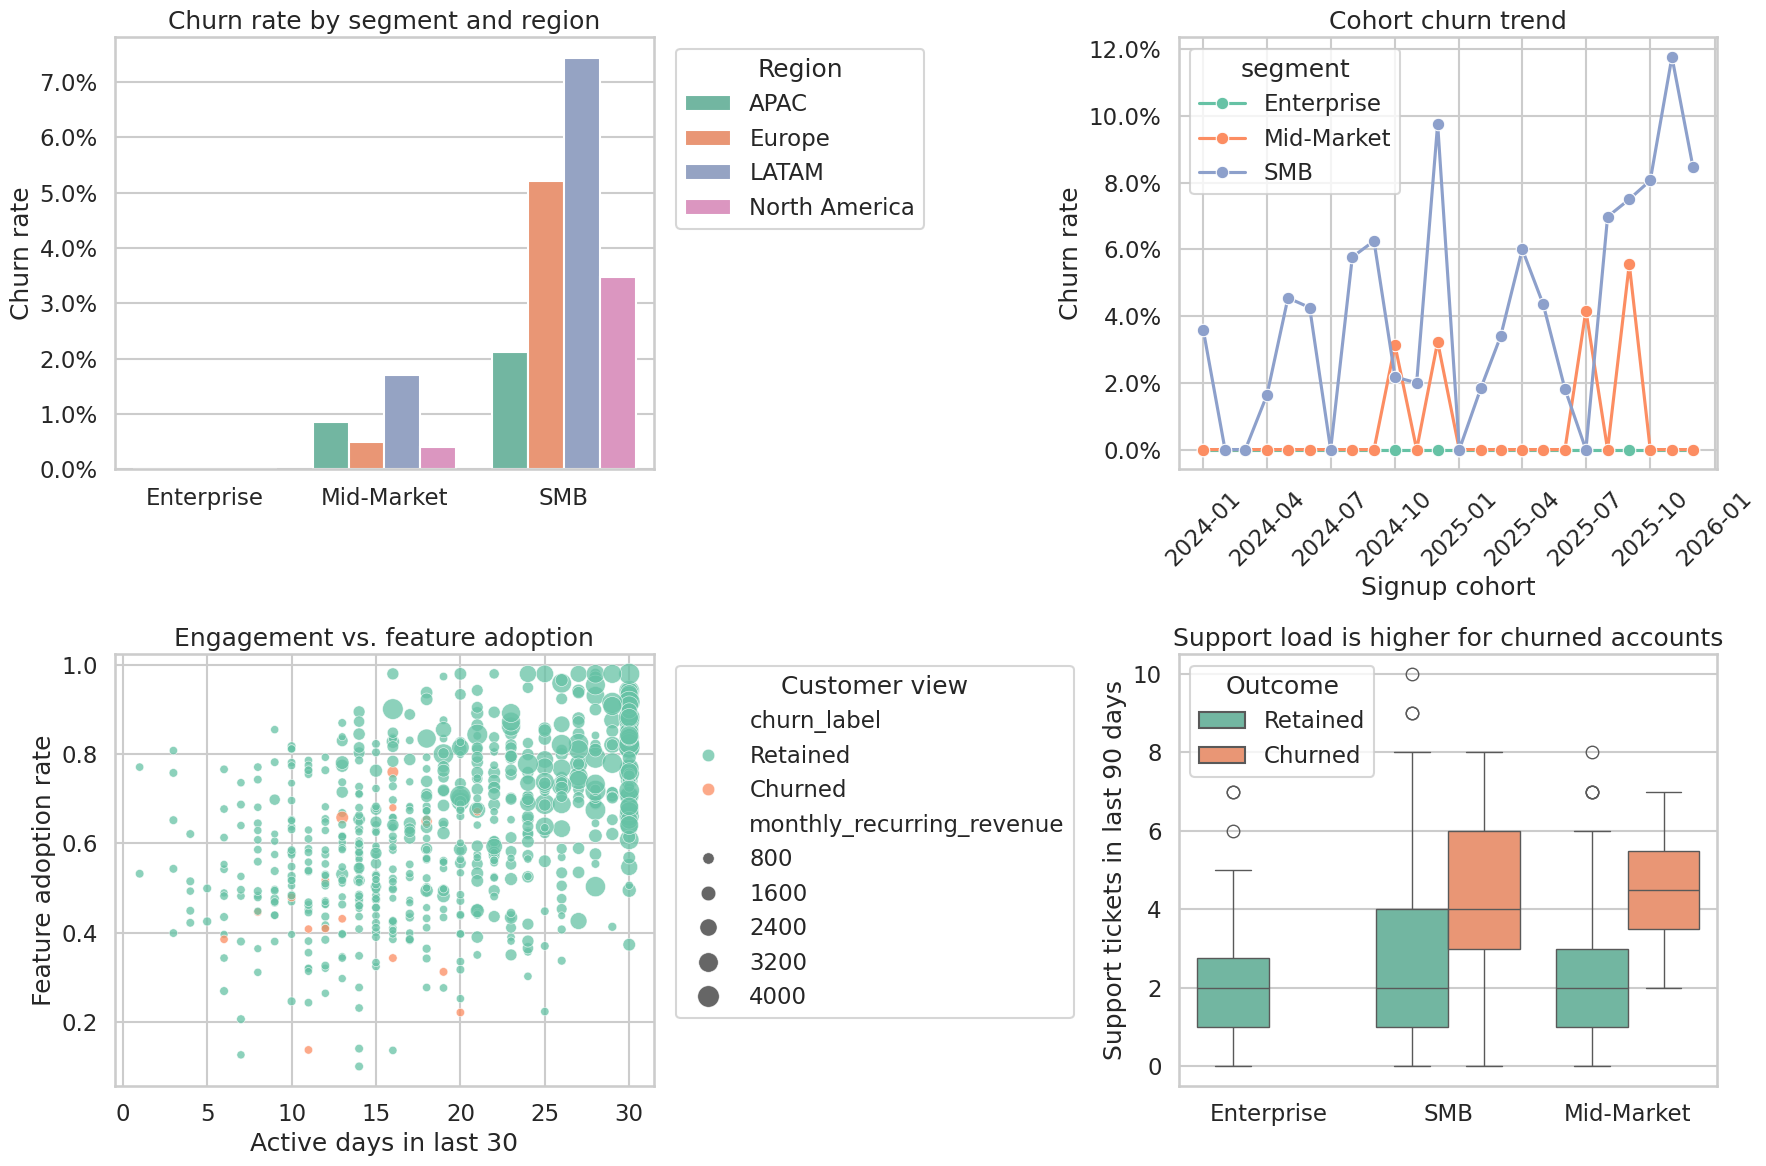

In [5]:
segment_region = customers.groupby(["segment", "region"], as_index=False).agg(churn_rate=("is_churned", "mean"), customers=("customer_id", "count"))
cohort_trend = customers.groupby(["cohort_month", "segment"], as_index=False).agg(churn_rate=("is_churned", "mean"), customers=("customer_id", "count"), avg_health_score=("health_score", "mean"))
sample = customers.sample(700, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=segment_region, x="segment", y="churn_rate", hue="region", ax=axes[0, 0])
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 0].set(title="Churn rate by segment and region", xlabel="", ylabel="Churn rate")
axes[0, 0].legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(data=cohort_trend, x="cohort_month", y="churn_rate", hue="segment", marker="o", ax=axes[0, 1])
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 1].set(title="Cohort churn trend", xlabel="Signup cohort", ylabel="Churn rate")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.scatterplot(data=sample, x="active_days_last_30", y="feature_adoption_rate", hue="churn_label", size="monthly_recurring_revenue", sizes=(30, 240), alpha=0.75, ax=axes[1, 0])
axes[1, 0].set(title="Engagement vs. feature adoption", xlabel="Active days in last 30", ylabel="Feature adoption rate")
axes[1, 0].legend(title="Customer view", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(data=customers, x="segment", y="support_tickets_last_90", hue="churn_label", ax=axes[1, 1])
axes[1, 1].set(title="Support load is higher for churned accounts", xlabel="", ylabel="Support tickets in last 90 days")
axes[1, 1].legend(title="Outcome")

plt.tight_layout()

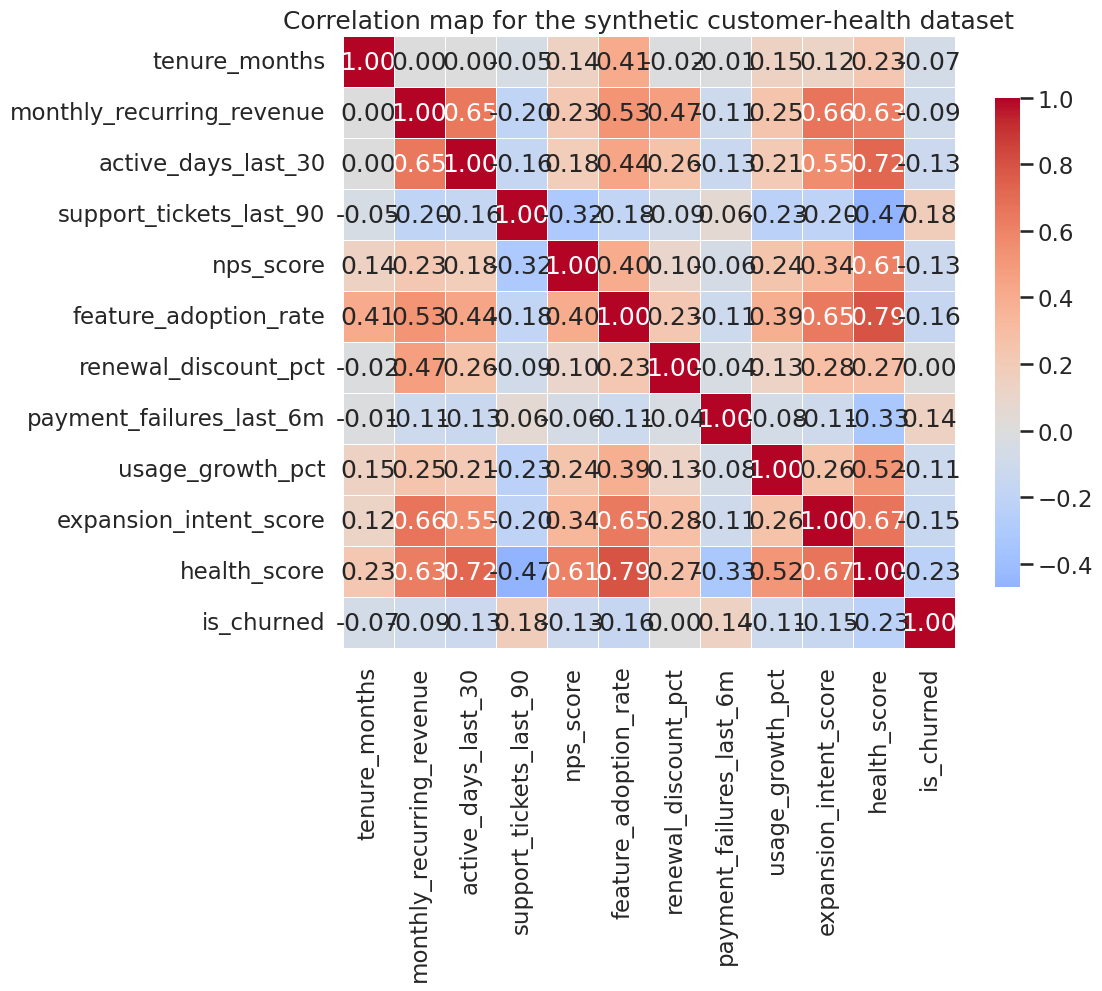

In [6]:
numeric_view = customers[["tenure_months", "monthly_recurring_revenue", "active_days_last_30", "support_tickets_last_90", "nps_score", "feature_adoption_rate", "renewal_discount_pct", "payment_failures_last_6m", "usage_growth_pct", "expansion_intent_score", "health_score", "is_churned"]]
corr = numeric_view.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation map for the synthetic customer-health dataset")
plt.tight_layout()

## Lightweight Modeling

The modeling section is intentionally compact. The point is not state-of-the-art prediction, but a structurally rich notebook section that later AI agents can critique, refactor, summarize, or explain to different audiences.

In [7]:
feature_columns = ["segment", "region", "acquisition_channel", "mrr_bucket", "tenure_months", "monthly_recurring_revenue", "active_days_last_30", "support_tickets_last_90", "nps_score", "feature_adoption_rate", "onboarding_hours", "renewal_discount_pct", "payment_failures_last_6m", "product_logins_last_30", "usage_growth_pct", "expansion_intent_score"]
categorical_features = ["segment", "region", "acquisition_channel", "mrr_bucket"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

X = customers[feature_columns]
y = customers["is_churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ])

models = {
    "Logistic regression": Pipeline(steps=[("preprocess", build_preprocessor()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random forest": Pipeline(steps=[("preprocess", build_preprocessor()), ("model", RandomForestClassifier(n_estimators=400, min_samples_leaf=4, random_state=42, class_weight="balanced"))]),
}

fitted_models = {}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
display(results_df.round(3))

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.802,0.093,0.846,0.168,0.906
1,Random forest,0.975,0.000,0.000,0.000,0.841


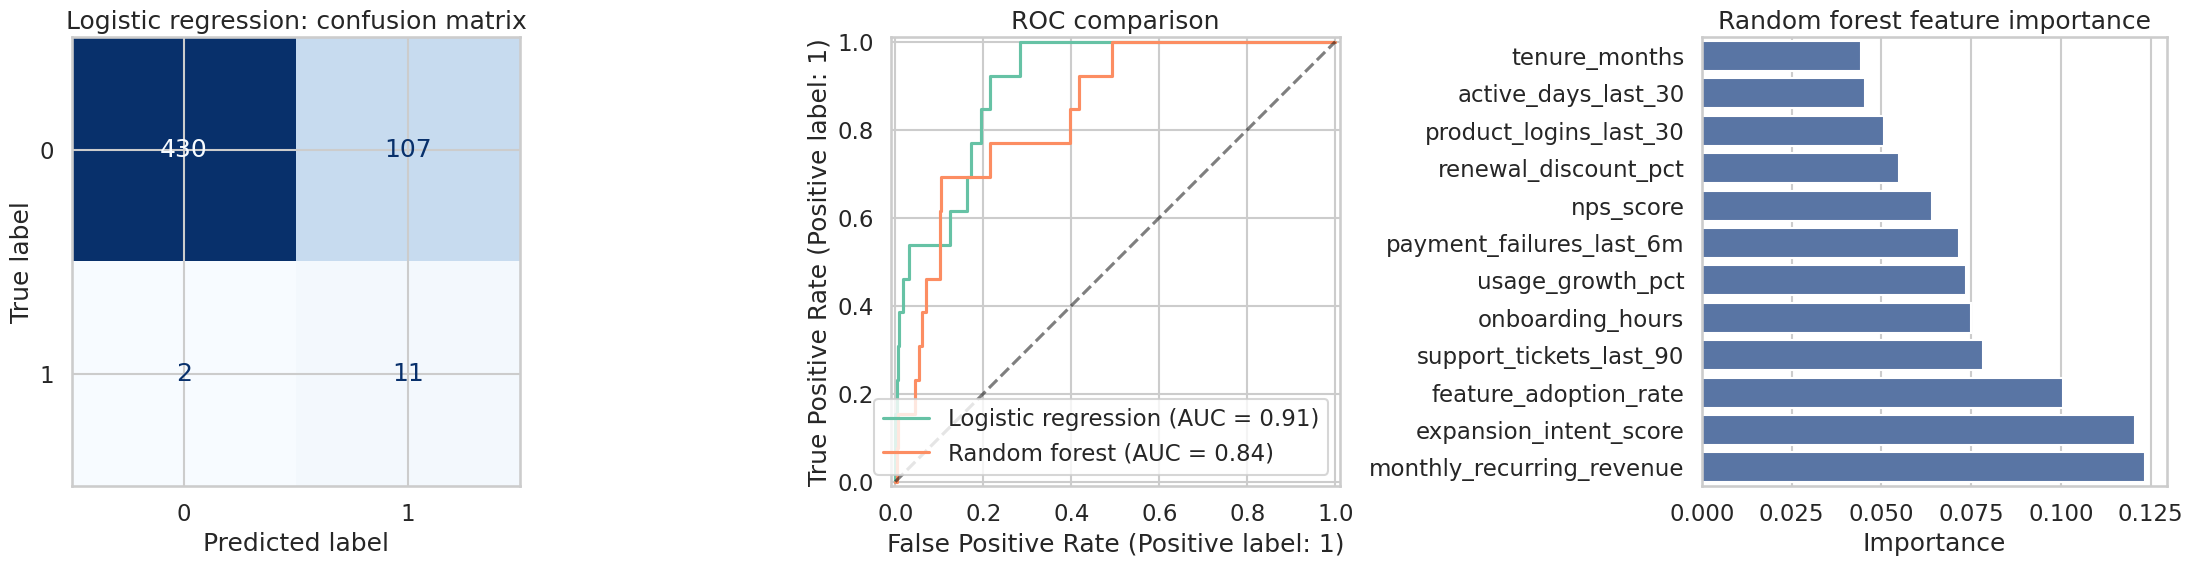

In [8]:
rf_pipeline = fitted_models["Random forest"]
rf_features = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_importances = pd.DataFrame({"feature": rf_features, "importance": rf_pipeline.named_steps["model"].feature_importances_})
rf_importances["feature"] = rf_importances["feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
top_features = rf_importances.nlargest(12, "importance").sort_values("importance")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title(f"{best_model_name}: confusion matrix")

for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black", alpha=0.5)
axes[1].set_title("ROC comparison")

sns.barplot(data=top_features, x="importance", y="feature", color="#4C72B0", ax=axes[2])
axes[2].set(title="Random forest feature importance", xlabel="Importance", ylabel="")

plt.tight_layout()

In [1]:
projection_features = ["tenure_months", "monthly_recurring_revenue", "active_days_last_30", "support_tickets_last_90", "nps_score", "feature_adoption_rate", "renewal_discount_pct", "payment_failures_last_6m", "usage_growth_pct", "expansion_intent_score"]
projection_ready = customers[projection_features].fillna(customers[projection_features].median(numeric_only=True))
projection_scaled = StandardScaler().fit_transform(projection_ready)
projection = PCA(n_components=2, random_state=42).fit_transform(projection_scaled)

projection_df = pd.DataFrame(projection, columns=["pc1", "pc2"])
projection_df["churn_label"] = customers["churn_label"].values
projection_df["segment"] = customers["segment"].values
projection_df["monthly_recurring_revenue"] = customers["monthly_recurring_revenue"].round(0).values

fig = px.scatter(projection_df, x="pc1", y="pc2", color="churn_label", symbol="segment", size="monthly_recurring_revenue", size_max=20, opacity=0.75, hover_data=["segment", "monthly_recurring_revenue"], title="Interactive projection of customer health states", labels={"pc1": "Principal component 1", "pc2": "Principal component 2"})
fig.update_layout(template="plotly_white", legend_title_text="")
fig

NameError: name 'customers' is not defined

## Future AI-Augmentation Hooks

This notebook is intentionally structured so later course work can attach AI support to realistic surfaces:

- narrative-code drift detection
- provenance summaries for figures and tables
- critique agents that challenge modeling choices
- adaptive explanations for novice versus expert readers
- goal-conditioned notebook expansion such as "explain the riskiest cohort"

That makes it a practical baseline artifact for exploring AI-enhanced literate programming.